
Available spectra:

6FBz_P2_260402
AP_6FBz@P2_1hCF_d1
B
BL
Baseline
BaselineA
BaselineB
CoMoB_CF_1
CoMoB_TS_R1_d1
CoMoB_TS_R2_d1
CoMoY_TS_R1_d1
CoMoY_TS_R2_d1
F005AP_6FBz@P2_CF_0402_d1
F005AP_6FBz@P2_CF_0528_d1
F005LP_6FBz@P2_CF_0528_d3
F005LP_6FBz@P2_CF_0528_d4
F006_R0_d20
F006_R1_d20
F006_R2_d20
H2O@P2_1hCF_d1
NI_BS_d4
NI_BS_d8
NI_TS_R1_d2
NI_TS_R2_d2
NoPo
NoPo_CF_1
NoPo_TS_R1_d1
NoPo_TS_R2_d1
P2R2A
P2R2B
P2R2C
P2R2D
P2_CF_1
P2_NoSon_CF_0317_d2_A
P2_NoSon_CF_0317_d2_B
P2_NoSon_CF_0528_d3_A
P2_NoSon_CF_0528_d3_B
P2_Ref_260217_BS
P2_Ref_260224_TS
P2_Reference_CF_0217_d1_weirdPlasmon
P2_TS_R1_d1
P2_TS_R2_d1
P2_TipSonR1_CF_0217_d1
P2_TipSonR2_CF_0224_d1
P2_TipSon_CF_0528_d1
Sample1
Sample2
Sample3
phDADQ_DMF_LowCon_d20
phDADQ_DMF_Sat_d20
phDADQ_DMF_Sat_d30


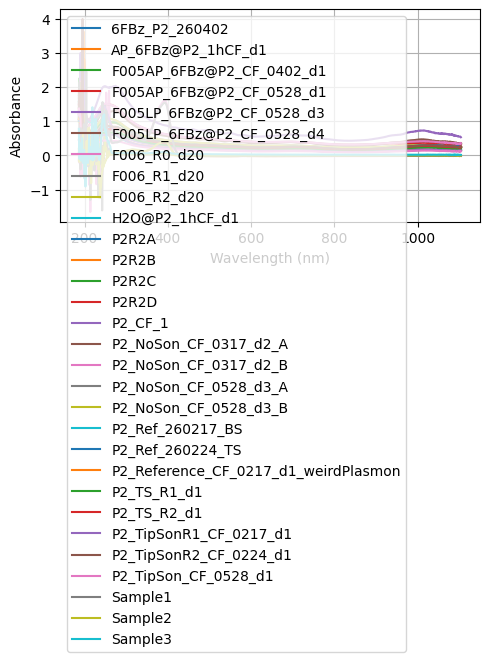

In [36]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add the root folder (where 'spectra' lives) to sys.path
ROOT = r"H:\FUBerlin\DataAnalysis"
if ROOT not in sys.path:
    sys.path.append(ROOT)

from spectra.io import load_absorption_csv  # now Python can find it

# === PROJECT AND DATA FOLDER ===


data_folders = [
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260226_Abs_CNTDispersions_TS',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260330_CNT_CF_PLE_P2_NoPo_CoMoCat',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260430_F005_6FBz_AP_1hCF',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260513_F005_6FBz_AP_1hCF_Refs',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260513_phDADQ_DMF',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260528_F006_phDADQ@P2_DMF_WashingSteps',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260529_F005_6FBz@P2_and_P2_References',
]

# === LOAD ALL CSV FILES IN THE FOLDERS ===
spectra_dict = {}

for data_folder in data_folders:
    for file in os.listdir(data_folder):
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(data_folder, file)
            spectra = load_absorption_csv(csv_path)

            for s in spectra:
                spectra_dict[s.N] = s




import numpy as np
import copy

def TrimSpectra(spectra_input, xmin=None, xmax=None):
    """
    Trim spectra to a given X range.

    Parameters
    ----------
    spectra_input : list or single spectrum
    xmin, xmax : float or None

    Returns
    -------
    list of trimmed spectra
    """

    if not isinstance(spectra_input, list):
        spectra_input = [spectra_input]

    trimmed_list = []

    for s in spectra_input:
        s_copy = copy.deepcopy(s)

        X = np.array(s_copy.X)
        Y = np.array(s_copy.Y)

        mask = np.ones_like(X, dtype=bool)

        if xmin is not None:
            mask &= (X >= xmin)
        if xmax is not None:
            mask &= (X <= xmax)

        X_new = X[mask]
        Y_new = Y[mask]

        if len(X_new) == 0:
            print(f"Warning: empty trim range for {s.N}")
            continue

        s_copy.X = X_new.tolist()
        s_copy.Y = Y_new.tolist()

        trimmed_list.append(s_copy)

    return trimmed_list


def Normalize(spectra_input, xmin, xmax, mode="I"):
    """
    Normalize spectra by integration or maximum within [xmin, xmax].

    Parameters
    ----------
    spectra_input : list or single spectrum object
    xmin : float
    xmax : float
    mode : str
        "I" -> normalize by integral
        "M" -> normalize by maximum

    Returns
    -------
    list of normalized spectrum objects
    """

    # Ensure input is always a list
    if not isinstance(spectra_input, list):
        spectra_input = [spectra_input]

    normalized_list = []

    for s in spectra_input:

        # Deep copy so original data stays untouched
        s_copy = copy.deepcopy(s)

        X = np.array(s_copy.X)
        Y = np.array(s_copy.Y)

        # Select wavelength window
        mask = (X >= xmin) & (X <= xmax)
        X_window = X[mask]
        Y_window = Y[mask]

        if len(X_window) == 0:
            print(f"Warning: No data in range for {s.N}")
            continue

        if mode.upper() == "I":
            # Integration normalization
            area = np.trapezoid(Y_window, X_window)
            if area != 0:
                Y = Y / area
            else:
                print(f"Warning: Zero integral for {s.N}")

        elif mode.upper() == "M":
            # Max normalization
            max_val = np.max(Y_window)
            if max_val != 0:
                Y = Y / max_val
            else:
                print(f"Warning: Zero max for {s.N}")

        else:
            raise ValueError("Mode must be 'I' (integration) or 'M' (maximum)")

        s_copy.Y = Y.tolist()
        s_copy.N = s_copy.N + f"_norm{mode.upper()}"

        normalized_list.append(s_copy)

    return normalized_list

def wavelength_to_energy(X_nm):
    X_nm = np.array(X_nm)
    return 1240.0 / X_nm

def PlotSpectra(
    spectra,
    mode="W",
    offset_step=0.0,
    xlabel_W="Wavelength (nm)",
    xlabel_E="Energy (eV)",
    ylabel="Absorbance",
):
    """
    mode:
        "W"  -> wavelength only
        "E"  -> energy only
        "WE" -> bottom Wavelength, top Energy
        "EW" -> bottom Energy, top Wavelength
    """

    fig, ax1 = plt.subplots(figsize=(5,5))

    # --- choose bottom axis ---
    for i, s in enumerate(spectra):

        X = np.array(s.X)
        Y = np.array(s.Y)
        y_offset = Y + i * offset_step

        if mode in ["W", "WE"]:
            ax1.plot(X, y_offset, label=s.N)
            ax1.set_xlabel(xlabel_W)

        elif mode in ["E", "EW"]:
            E = wavelength_to_energy(X)
            ax1.plot(E, y_offset, label=s.N)
            ax1.set_xlabel(xlabel_E)

    ax1.set_ylabel(ylabel)
    ax1.grid(True)

    # --- dual axis ---
    if mode in ["WE", "EW"]:

        ax2 = ax1.twiny()

        if mode == "WE":
            # bottom = W, top = E
            ax2.set_xlabel(xlabel_E)

            w_ticks = ax1.get_xticks()
            ax2.set_xticks(w_ticks)
            ax2.set_xticklabels(np.round(1240 / np.array(w_ticks), 2))

        elif mode == "EW":
            # bottom = E, top = W
            ax2.set_xlabel(xlabel_W)

            e_ticks = ax1.get_xticks()
            ax2.set_xticks(e_ticks)
            ax2.set_xticklabels(np.round(1240 / np.array(e_ticks), 1))

    ax1.legend()
    plt.tight_layout()
    plt.show()


    # === SUMMARY ===

print("\nAvailable spectra:\n")

for name in sorted(spectra_dict.keys()):
    print(name)

    # === SELECT ====

selected_names = [
    "6FBz_P2_260402",
    "AP_6FBz@P2_1hCF_d1",
    "F005AP_6FBz@P2_CF_0402_d1",
    "F005AP_6FBz@P2_CF_0528_d1",
    "F005LP_6FBz@P2_CF_0528_d3",
    "F005LP_6FBz@P2_CF_0528_d4",
    "F006_R0_d20",
    "F006_R1_d20",
    "F006_R2_d20",
    "H2O@P2_1hCF_d1",
    "P2R2A", 
    "P2R2B", 
    "P2R2C", 
    "P2R2D", 
    "P2_CF_1",
    "P2_NoSon_CF_0317_d2_A", 
    "P2_NoSon_CF_0317_d2_B", 
    "P2_NoSon_CF_0528_d3_A", 
    "P2_NoSon_CF_0528_d3_B", 
    "P2_Ref_260217_BS", 
    "P2_Ref_260224_TS", 
    "P2_Reference_CF_0217_d1_weirdPlasmon", 
    "P2_TS_R1_d1", 
    "P2_TS_R2_d1", 
    "P2_TipSonR1_CF_0217_d1", 
    "P2_TipSonR2_CF_0224_d1", 
    "P2_TipSon_CF_0528_d1", 
    "Sample1", 
    "Sample2", 
    "Sample3"
    ]



# === OPTIONAL: simple plot ===
    
if(0==1):
    plt.figure(figsize=(5,5))

    offset = 0.0

    for name in selected_names:
        if name in spectra_dict:
            s = spectra_dict[name]
            plt.plot(s.X, s.Y, label=name)
        else:
            print(f"Warning: {name} not found!")

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Absorbance")
    plt.xlim(200,1100)
    #plt.ylim(0,3)
    plt.title("Absorption Spectra")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if(0==1):
    plt.figure(figsize=(5,5))

    offset_step = 0.1   # <-- adjust spacing here

    for i, s in enumerate(selected_spectra):
        y_offset = np.array(s.Y) + i * offset_step
        plt.plot(s.X, y_offset, label=s.N)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Absorbance")
    plt.title("Absorption Spectra (Integral Normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



selected_spectra = [spectra_dict[name] for name in selected_names]
#selected_spectra = TrimSpectra(selected_spectra, 270, 500)
#selected_spectra = Normalize(selected_spectra, 350, 420, mode="M")
PlotSpectra(selected_spectra, 'W')